# Introduction 
The Goal of this project is to show how social structures prevelent in 16th century Italy influenced the spread of the plague. This file will show how there is a difference in demographics and plague spread. 

# Load in Relevant Libraries: 

In [8]:
import pandas as pd
import numpy as np
import glob 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load in Cleaned Data Sets and Create Combined Data Set

In [16]:
clean_1630_data = pd.read_csv('cleaned_plague_data_1630.csv')

In [48]:
# Standardize Data
clean_1630_data.columns = clean_1630_data.columns.str.strip()
clean_1630_data = clean_1630_data.rename(columns={'Type of death' : 'Type of Death'})

In [89]:
clean_1630_data['Date'] = pd.to_datetime(clean_1630_data['Date'])

In [90]:
clean_1630_data.head()

,Date,Age,Sex,Cause of Death,Days Afflicted,Type of Death,Days Since Start,Plague Flag,Age Group
0,1900-01-03,22,F,Fever From Plague,60,Plague Death,0 days,1,Young Adult
1,1900-01-04,25,F,Fever From Plague,60,Plague Death,1 days,1,Young Adult
2,1900-01-04,14,M,Fever From Plague,60,Plague Death,1 days,1,Teen
3,1900-01-08,14,M,Fever From Plague,60,Plague Death,5 days,1,Teen
4,1900-01-08,5,M,Fever From Plague,60,Plague Death,5 days,1,Child


In [18]:
clean_1631_data = pd.read_csv('cleaned_plague_data_1631.csv')

In [50]:
# Standardize Data
clean_1631_data.columns = clean_1631_data.columns.str.strip()
clean_1631_data = clean_1631_data.rename(columns={ "Afflicted Time (Days" : "Days Afflicted"})	

In [94]:
clean_1631_data['Date'] = pd.to_datetime(clean_1631_data['Date'])

In [51]:
clean_1631_data.head()

,Date,Age,Sex,Cause of Death,Days Afflicted,Type of Death,Days Since Start,Plague Flag,Age Group
0,1900-01-01,60,M,Coal,5,Non-Plague Death,0 days,0,Older Adult
1,1900-01-03,73,F,apoplexy,365,Non-Plague Death,2 days,0,Older Adult
2,1900-01-04,5,M,Infection,3,Non-Plague Death,3 days,0,Child
3,1900-01-04,108,F,Plague and Old age,1095,Plague Death,3 days,1,Older Adult
4,1900-01-04,50,M,Plague,10,Plague Death,3 days,1,Middle Age


In [96]:
combined = pd.concat([clean_1630_data, clean_1631_data]).dropna(axis=1, how='all')

In [97]:
combined.head()

,Date,Age,Sex,Cause of Death,Days Afflicted,Type of Death,Days Since Start,Plague Flag,Age Group
0,1900-01-03,22,F,Fever From Plague,60,Plague Death,0 days,1,Young Adult
1,1900-01-04,25,F,Fever From Plague,60,Plague Death,1 days,1,Young Adult
2,1900-01-04,14,M,Fever From Plague,60,Plague Death,1 days,1,Teen
3,1900-01-08,14,M,Fever From Plague,60,Plague Death,5 days,1,Teen
4,1900-01-08,5,M,Fever From Plague,60,Plague Death,5 days,1,Child


# Create Tables

 Gender and plague Tables: 

In [113]:
# Plague Deaths by Gender in 1630
gender_plague_1630 = (
    clean_1630_data[clean_1630_data['Sex'] != 'Unkown']
    .groupby(['Sex', 'Type of Death'])
    .size()
    .unstack(fill_value=0)
)
gender_plague_1630

Type of Death,Non-Plague Death,Plague Death
Sex,,
F,92,380
M,92,353


In [114]:
# Plague Deaths by Gender in 1631
gender_plague_1631 = clean_1631_data.groupby(['Sex' , 'Type of Death']).size().unstack(fill_value=0)
gender_plague_1631

Type of Death,Non-Plague Death,Plague Death
Sex,,
F,218,211
M,200,210


In [115]:
# Plague Deaths by Gender from 1630-31
gender_plague_both = (
    combined[combined['Sex'] != 'Unkown']
    .groupby(['Sex', 'Type of Death'])
    .size()
    .unstack(fill_value=0)
)
gender_plague_both

Type of Death,Non-Plague Death,Plague Death
Sex,,
F,310,591
M,292,563


Plague Deaths by Age

In [116]:
# Plague Deaths by Age Groups in 1630
age_plague_1630 = clean_1630_data.groupby(['Age Group' , 'Type of Death']).size().unstack(fill_value=0)
age_plague_1630

Type of Death,Non-Plague Death,Plague Death
Age Group,,
Child,83,237
Infant,50,25
Middle Age,10,128
Older Adult,4,72
Teen,10,105
Young Adult,28,166


In [117]:
# Plague Deaths by Age Groups in 1631
age_plague_1631 = clean_1631_data.groupby(['Age Group' , 'Type of Death']).size().unstack(fill_value=0)
age_plague_1631 

Type of Death,Non-Plague Death,Plague Death
Age Group,,
Child,151,141
Infant,25,20
Middle Age,57,75
Older Adult,30,39
Teen,51,56
Young Adult,104,90


In [118]:
# Plague Deaths by Age Groups from 1630-31
age_plague_both = combined.groupby(['Age Group' , 'Type of Death']).size().unstack(fill_value=0)
age_plague_1631 

Type of Death,Non-Plague Death,Plague Death
Age Group,,
Child,151,141
Infant,25,20
Middle Age,57,75
Older Adult,30,39
Teen,51,56
Young Adult,104,90


Plague Deaths by Date 

In [119]:
# 1630 Plague Deaths by Months
monthly_deaths_1630 = pd.crosstab(
    clean_1630_data['Date'].dt.to_period('M'),
    clean_1630_data['Type of Death']
)
monthly_deaths_1630

Type of Death,Non-Plague Death,Plague Death
Date,,
1900-01,2,17
1900-02,6,14
1900-03,9,3
1900-04,1,6
1900-05,8,8
1900-06,14,7
1900-07,10,23
1900-08,3,14
1900-09,2,20


In [120]:
# 1631 Plague Deaths by Months
monthly_deaths_1631 = pd.crosstab(
    clean_1631_data['Date'].dt.to_period('M'),
    clean_1631_data['Type of Death']
)
monthly_deaths_1631

Type of Death,Non-Plague Death,Plague Death
Date,,
1900-01,29,45
1900-02,41,51
1900-03,57,72
1900-04,53,76
1900-05,39,63
1900-06,61,63
1900-07,64,20
1900-08,35,11
1900-09,28,7


In [100]:
# 1630-31 Plague Deaths by Months
monthly_deaths_combined = pd.crosstab(
    combined['Date'].dt.to_period('M'),
    combined['Type of Death']
)
monthly_deaths_combined

Type of Death,Non-Plague Death,Plague Death
Date,,
1900-01,31,62
1900-02,47,65
1900-03,66,75
1900-04,54,82
1900-05,47,71
1900-06,75,70
1900-07,74,43
1900-08,38,25
1900-09,30,27


# Visual Analysis

Plague Deaths By Gender

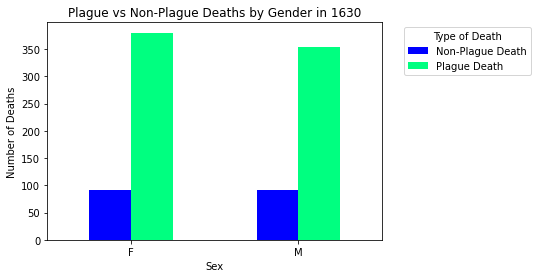

<Figure size 432x288 with 0 Axes>

In [126]:
# For 1630
gender_plague_1630.plot(kind='bar', colormap='winter')
plt.legend(
    title='Type of Death',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.title('Plague vs Non-Plague Deaths by Gender in 1630')
plt.xlabel('Sex')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=0)
plt.show()
plt.clf()

From this bar graph we can see that women are dying from the plague at a higher rate then men. we can also see that this is a "plague" year, in that plague deaths are significantly higher then any other type of deaths this year. 

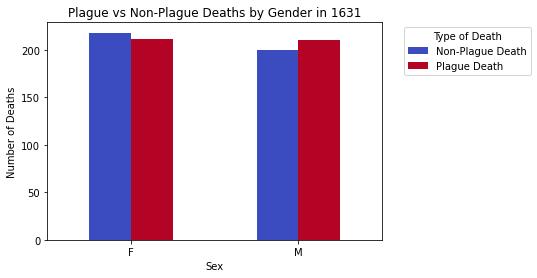

<Figure size 432x288 with 0 Axes>

In [127]:
# For 1631
gender_plague_1631.plot(kind='bar', colormap='coolwarm')
plt.legend(
    title='Type of Death',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.title('Plague vs Non-Plague Deaths by Gender in 1631')
plt.xlabel('Sex')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=0)
plt.show()
plt.clf()

We see in 1631 the plague has significantly calmed down in that the amount of people dying due to the plague is much closer to the amount of people dying for other unrelated causes. Interestingly, males are still dying a bit more due to the plague then other reasons but have mostly leveled out with females. 

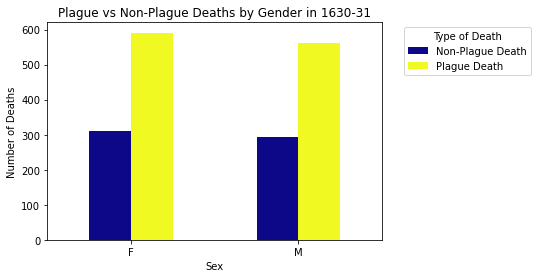

<Figure size 432x288 with 0 Axes>

In [129]:
# 1630-31
gender_plague_both.plot(kind='bar', colormap='plasma')
plt.legend(
    title='Type of Death',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.title('Plague vs Non-Plague Deaths by Gender in 1630-31')
plt.xlabel('Sex')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=0)
plt.show()
plt.clf()

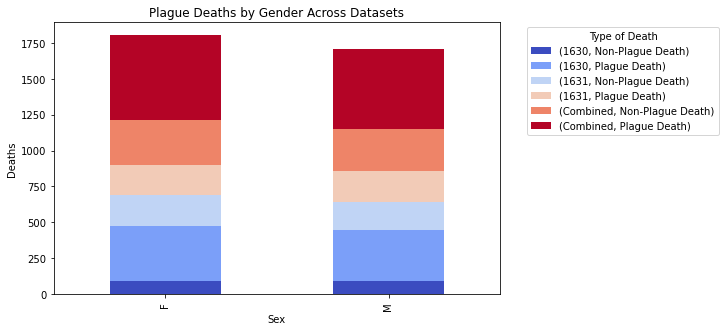

<Figure size 432x288 with 0 Axes>

In [135]:
# Stacked Bar Chart 
comparison = pd.concat(
    {
        '1630': gender_plague_1630,
        '1631': gender_plague_1631,
        'Combined': gender_plague_both
    },
    axis=1
)
comparison.plot(
    kind='bar',
    colormap='coolwarm',
    stacked=True,
    figsize=(8,5)
)
plt.legend(
    title='Type of Death',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.title('Plague Deaths by Gender Across Datasets')
plt.ylabel('Deaths')
plt.show()
plt.clf()

In this bar graph we see that women are overall dying more due to the plague then men are. This stacked bar graph also strengthens our assertion that the plague was beginning to die out in 1631 and was peaking in 1630.

Age Distribution of Plague Victims

In [ ]:
# Only Looking at Plague Deaths 
plague_only_1630 = clean_1630_data[
    clean_1630_data['Type of Death'] == 'Plague Death'
]
plague_only_1631 = clean_1631_data[
    clean_1631_data['Type of Death'] == 'Plague Death'
]

<AxesSubplot:xlabel='Age', ylabel='Count'>

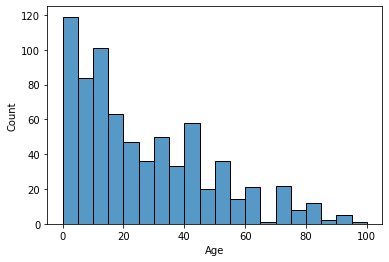

In [144]:
# Histogram for Plague Deaths and Ages in 1630
sns.histplot(plague_only_1630['Age'], bins=20)

This histogram shows that the younger population (under 20) had the largest share of plague deaths, this indicates that there is a heightened vulnerability among younger individuals during the epidemic. This is interesting because young adults tend to be the most socially and economically active segment of the population, which may reflect greater exposure through work, household interactions, and community contacts.

<AxesSubplot:xlabel='Age', ylabel='Count'>

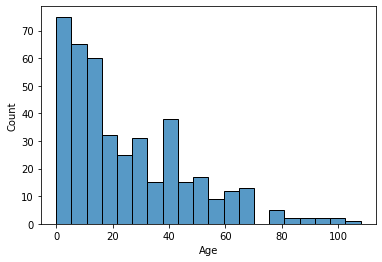

In [145]:
# Histogram for Plague Deaths and Ages in 1631
sns.histplot(plague_only_1631['Age'], bins=20)

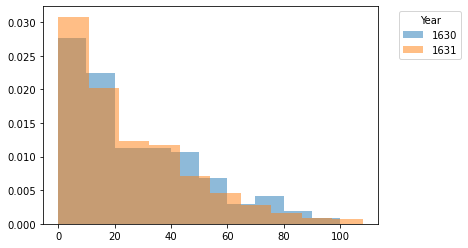

<Figure size 432x288 with 0 Axes>

In [148]:
plt.hist(plague_only_1630['Age'], label='1630', density=True, alpha=.5)
plt.hist(plague_only_1631['Age'], label='1631', density=True, alpha=.5)
plt.legend(
    title='Year',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.show()
plt.clf()

This histogram shows that while younger populations are more vulnerable they were more impacted in 1630 rather then 1631. This is conducive with our assumption that the outbreak of this plague happened in 1630. 

Plague Deaths by Age Group 

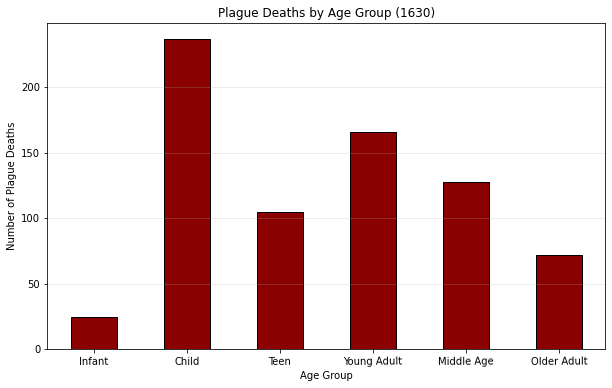

<Figure size 432x288 with 0 Axes>

In [161]:
# Age Groups and Plague Deaths 1630
age_order = [
    'Infant',
    'Child',
    'Teen',
    'Young Adult',
    'Middle Age',
    'Older Adult'
]

age_counts_30 = (
    plague_only_1630['Age Group']
    .value_counts()
    .reindex(age_order)
)
plt.figure(figsize=(10,6))
age_counts_30.plot(
    kind='bar',
    color='darkred',
    edgecolor='black'
)
plt.xticks(rotation=0.5)
plt.grid(axis='y', alpha=0.3)
plt.title('Plague Deaths by Age Group (1630)')
plt.ylabel('Number of Plague Deaths')
plt.xlabel('Age Group')
plt.show()
plt.clf()

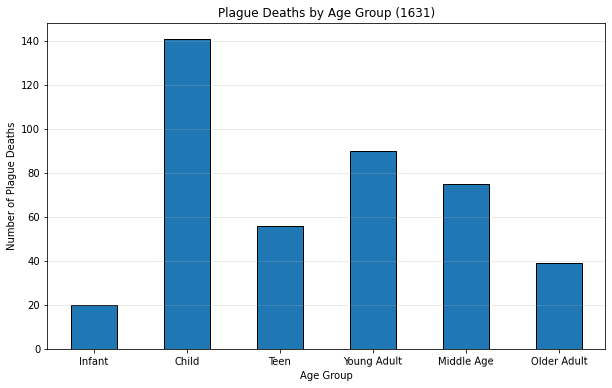

In [164]:
# Age Groups and Plague Deaths 1631
age_counts_31 = (
    plague_only_1631['Age Group']
    .value_counts()
    .reindex(age_order)
)
plt.figure(figsize=(10,6))
age_counts_31.plot(
    kind='bar',
    edgecolor='black'
)
plt.xticks(rotation=0.5)
plt.grid(axis='y', alpha=0.3)
plt.title('Plague Deaths by Age Group (1631)')
plt.ylabel('Number of Plague Deaths')
plt.xlabel('Age Group')
plt.show()

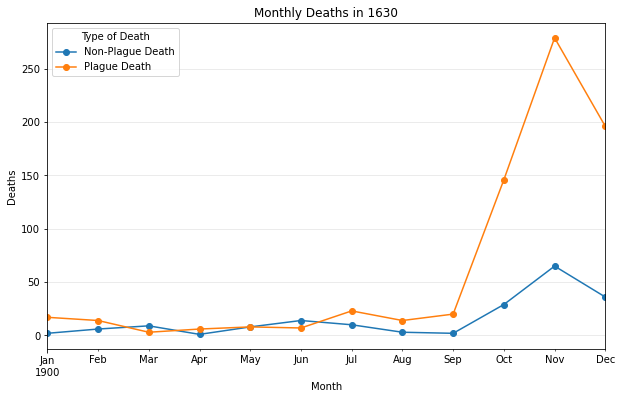

<Figure size 432x288 with 0 Axes>

In [173]:
# Monthly deaths in 1630
monthly_deaths_1630.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.title('Monthly Deaths in 1630')
plt.xlabel('Month')
plt.ylabel('Deaths')
plt.grid(alpha=0.3)
plt.show()
plt.clf()

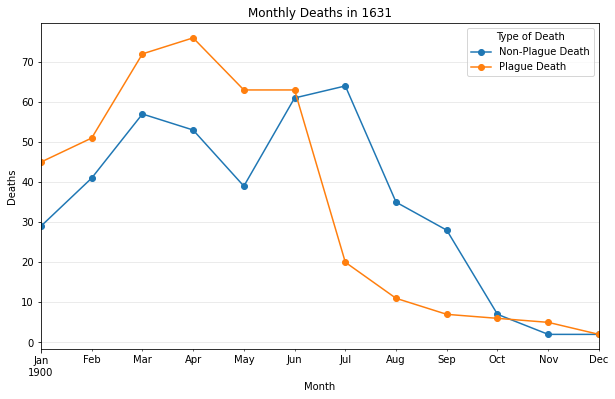

<Figure size 432x288 with 0 Axes>

In [174]:
# Monthly deaths in 1631
monthly_deaths_1631.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.title('Monthly Deaths in 1631')
plt.xlabel('Month')
plt.ylabel('Deaths')
plt.grid(alpha=0.3)
plt.show()
plt.clf()

From these two line graphs we can see that the plague outbreak peaked from October of 1630 to April 1631. 